# LoL Minimap Champion Detection - Project Report

This notebook is a lightweight portfolio report.

Production scripts live in `src/`:
- `src/generate_synth_data.py`
- `src/split_dataset.py`
- `src/train.py`
- `src/evaluate.py`
- `src/infer_live.py`


## Objective
Detect ally/enemy champions on the League of Legends minimap in real time using a YOLO detector trained on synthetic data.


## Reproducible CLI Workflow
Run the full pipeline from scripts (not this notebook):

```powershell
powershell -ExecutionPolicy Bypass -File scripts/run_all.ps1
```


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

PROJECT_ROOT = Path.cwd()
RUN_DIR = PROJECT_ROOT / 'runs' / 'detect' / 'minimap_champion_detector'
print('Project root:', PROJECT_ROOT)
print('Run dir exists:', RUN_DIR.exists())


Project root: c:\Users\knut1\Documents\Computer_Vision\LoL_Project
Run dir exists: True


## Final Training Metrics
This reads `results.csv` produced by Ultralytics training and shows final epoch metrics.


In [2]:
results_csv = RUN_DIR / 'results.csv'
if results_csv.exists():
    df = pd.read_csv(results_csv)
    display(df.tail(1))

    cols = [c for c in df.columns if 'metrics/' in c or 'loss' in c]
    display(df[cols].tail(5))
else:
    print('No results.csv found at', results_csv)


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
99,100,101.08,0.39649,0.32511,0.81253,0.97565,0.8886,0.94841,0.87567,0.36196,0.31147,0.79095,0.000014,0.000014,0.000014


,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss
95,0.37817,0.31018,0.80543,0.96702,0.89321,0.94709,0.87814,0.36314,0.30898,0.79125
96,0.37513,0.31504,0.80482,0.98190,0.88019,0.94710,0.87419,0.37561,0.31034,0.79197
97,0.40991,0.32533,0.80281,0.98395,0.88217,0.94798,0.87084,0.37819,0.31240,0.79198
98,0.39003,0.31308,0.81055,0.98400,0.88239,0.94810,0.87174,0.37368,0.31233,0.79166
99,0.39649,0.32511,0.81253,0.97565,0.88860,0.94841,0.87567,0.36196,0.31147,0.79095


## Training Curves


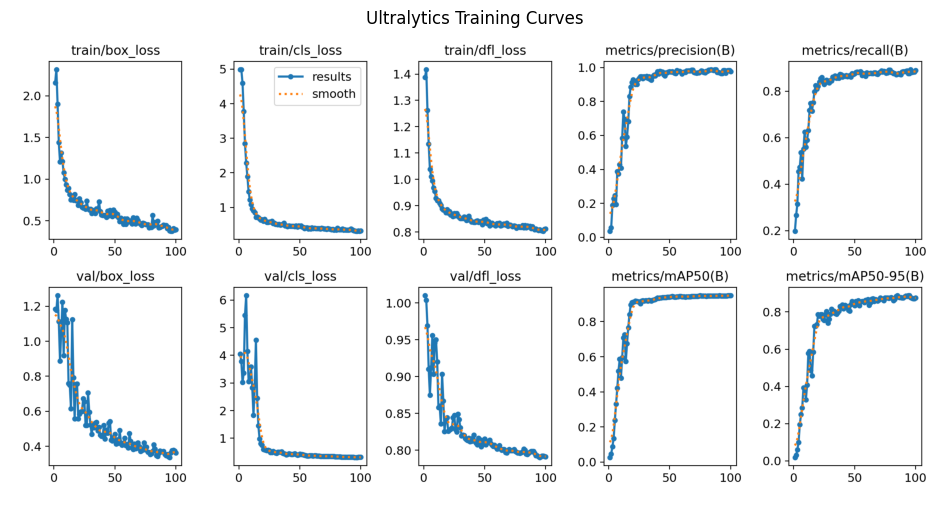

In [3]:
plot_path = RUN_DIR / 'results.png'
if plot_path.exists():
    img = Image.open(plot_path)
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Ultralytics Training Curves')
    plt.show()
else:
    print('No results.png found at', plot_path)


## Validation Visuals
Confusion matrix, PR curve, and a sample prediction image.


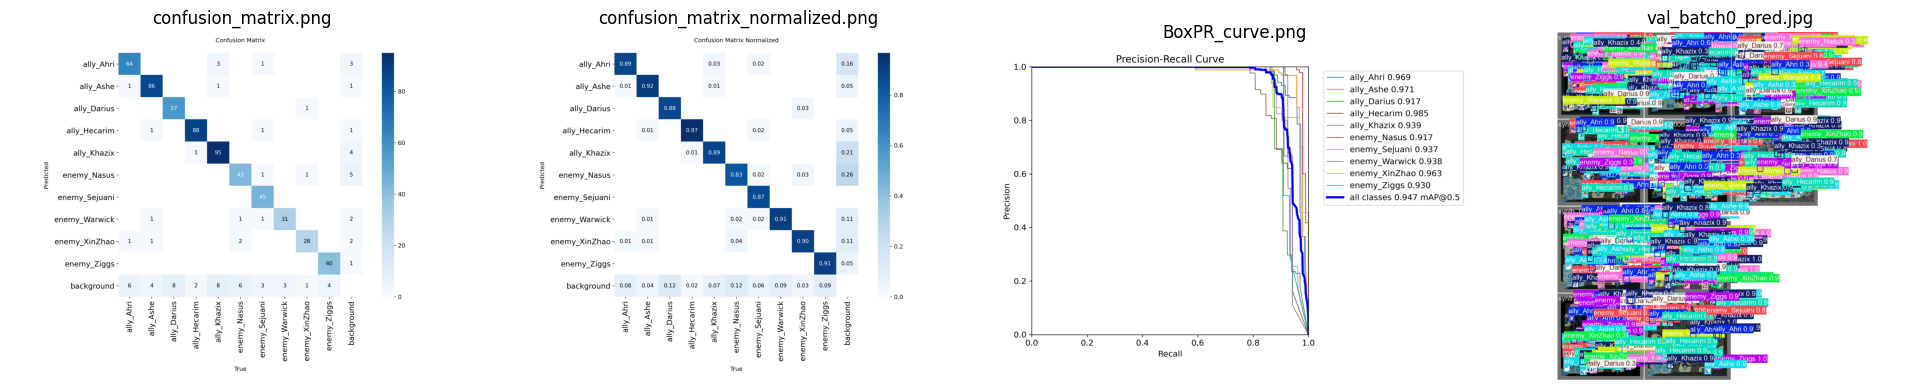

In [4]:
artifact_names = [
    'confusion_matrix.png',
    'confusion_matrix_normalized.png',
    'BoxPR_curve.png',
    'val_batch0_pred.jpg',
]

existing = [RUN_DIR / name for name in artifact_names if (RUN_DIR / name).exists()]
if not existing:
    print('No expected validation artifacts found in', RUN_DIR)
else:
    n = len(existing)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1:
        axes = [axes]

    for ax, p in zip(axes, existing):
        ax.imshow(Image.open(p))
        ax.set_title(p.name)
        ax.axis('off')

    plt.tight_layout()
    plt.show()


## Live Inference
Run live detection with:

```powershell
python src/infer_live.py --model runs/detect/minimap_champion_detector/weights/best.pt
```

Legacy wrapper still supported:

```powershell
python windowCapture.py
```
